In [247]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pyarrow as pa
import light_curve as licu


from nested_pandas import NestedDtype
from nested_pandas import NestedFrame, read_parquet
from nested_pandas.datasets import generate_parquet_file

In [248]:
bad_lcs_path = "/home/mathilda/shared_anomaly/data/ecdfs_1k.parquet"
print(os.path.exists(bad_lcs_path))

True


In [249]:
bad_lcs = read_parquet(bad_lcs_path)

In [250]:
bad_lcs

diaObjectForcedSource          _healpix_29
0     [{band: 'g', coord_dec: -28.196675, coord_ra: ...  2528713666380974602
1     [{band: 'g', coord_dec: -28.196735, coord_ra: ...  2528713666714509580
...                                                 ...                  ...
1090  [{band: 'g', coord_dec: -28.005428, coord_ra: ...  2528742752753587913
1091  [{band: 'g', coord_dec: -28.004336, coord_ra: ...  2528742758208346296

[1092 rows x 2 columns]

In [211]:
u = bad_lcs.loc[888]["diaObjectForcedSource"]

In [212]:
for band in ["u","g","r","i","z","y"]:
    print(band,":",len(u[u["band"]==band]))

u : 10
g : 50
r : 47
i : 87
z : 58
y : 10


In [215]:
u[u["band"]=="u"]

,band,coord_dec,coord_ra,diff_PixelFlags_nodataCenter,invalidPsfFlag,midpointMjdTai,pixelFlags_bad,pixelFlags_cr,pixelFlags_crCenter,pixelFlags_edge,...,pixelFlags_suspectCenter,psfDiffFlux,psfDiffFlux_flag,psfDiffFluxErr,psfFlux,psfFlux_flag,psfFluxErr,psfMag,psfMagErr,visit
154,u,-28.039577,53.069946,False,False,60995.085451,False,False,False,False,...,False,-613.757874,False,1084.951782,203831.765625,False,958.147095,18.126820,0.005104,2025111500098
155,u,-28.039577,53.069946,False,False,60995.086248,False,False,False,False,...,False,-504.661285,False,1090.723633,202372.671875,False,968.249390,18.134621,0.005195,2025111500099
156,u,-28.039577,53.069946,False,False,60997.049691,False,False,False,False,...,False,-2614.587891,False,1286.628052,199504.390625,False,1229.308594,18.150120,0.006690,2025111700047
157,u,-28.039577,53.069946,False,False,60997.050149,False,False,False,False,...,False,218.385635,False,1310.067383,202866.375000,False,1256.950928,18.131975,0.006727,2025111700048
158,u,-28.039577,53.069946,False,False,60997.050604,False,False,False,False,...,False,1688.521606,False,1374.998535,205071.265625,False,1338.501709,18.120237,0.007087,2025111700049
163,u,-28.039577,53.069946,False,False,61002.233860,False,False,False,False,...,False,-108.375160,False,1059.006958,202206.921875,False,962.580505,18.135509,0.005169,2025112200252
164,u,-28.039577,53.069946,False,False,61002.234320,False,False,False,False,...,False,-382.896973,False,1084.747070,202917.312500,False,981.619202,18.131702,0.005252,2025112200253
165,u,-28.039577,53.069946,False,False,61002.234795,False,False,False,False,...,False,1358.632568,False,1092.451904,204263.531250,False,986.843811,18.124523,0.005245,2025112200254
204,u,-28.039577,53.069946,False,False,61030.289949,False,False,False,False,...,False,-1912.886597,False,1188.023438,206848.671875,False,1119.007935,18.110868,0.005874,2025122000265
205,u,-28.039577,53.069946,False,False,61030.290501,False,False,False,False,...,False,2571.718506,False,1279.313599,207592.343750,False,1212.075562,18.106972,0.006339,2025122000266


<ErrorbarContainer object of 3 artists>

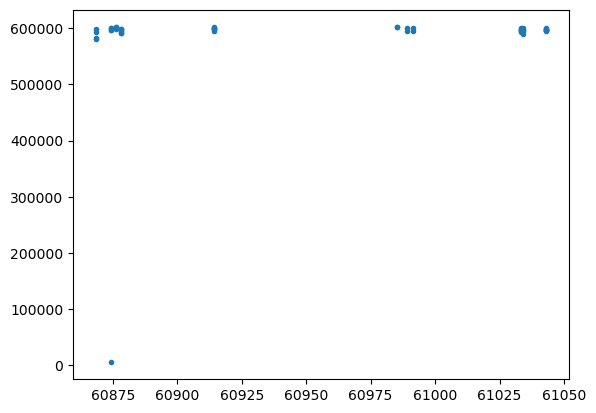

In [108]:
filt = u["band"]=="g"

plt.errorbar(u["midpointMjdTai"][filt],u["psfFlux"][filt],yerr=u["psfFluxErr"][filt],fmt = ".")

In [109]:
print(u["coord_ra"][0],u["coord_dec"][0])

53.06994607398453 -28.03957741273639


In [143]:
import light_curve as licu
import nested_pandas as npd
import numpy as np
import pyarrow as pa
from upath import UPath

s3_path = UPath(
    "s3://ipac-irsa-ztf/contributed/dr23/lc/hats/ztf_dr23_lc-hats/dataset/Norder=6/Dir=30000/Npix=34623/part0.snappy.parquet",
    anon=True,
)
ndf = npd.read_parquet(
    s3_path,
    columns=["objectid", "lightcurve.hmjd", "lightcurve.mag", "lightcurve.magerr"],
)

ndf = ndf.loc[ndf["lightcurve"].len() > 10]

ndf["lightcurve.t"] = np.asarray(ndf["lightcurve.hmjd"] - 58000, dtype=np.float32)

feature = licu.Extractor(licu.Chi2Pvar(), licu.InterPercentileRange(quantile=0.25), licu.LinearFit())
result = feature.many(pa.array(ndf["lightcurve"]), n_jobs=-1,
                      arrow_fields={"t": "t", "m": "mag", "sigma": "magerr"})

ndf = ndf.assign(**dict(zip(feature.names, result.T)))
ndf.head()

objectid                                         lightcurve  \
0  1248202100002710  [{hmjd: 59176.3144, mag: 19.841591, magerr: 0....   
1  1248202100002733  [{hmjd: 59176.31488, mag: 19.836166, magerr: 0...   
2  1248202100002739  [{hmjd: 59124.43823, mag: 19.081635, magerr: 0...   
5  1248202100002819  [{hmjd: 59124.43823, mag: 17.424206, magerr: 0...   
8  1248202100002918  [{hmjd: 59124.43823, mag: 18.022591, magerr: 0...   

      chi2_pvar  inter_percentile_range_25  linear_fit_slope  \
0  7.993606e-15                   0.305351          0.001163   
1  2.044478e-01                   0.216278          0.000245   
2  7.342844e-01                   0.092379          0.000048   
5  1.201204e-04                   0.042589          0.000031   
8  8.479147e-03                   0.045643          0.000043   

   linear_fit_slope_sigma  linear_fit_reduced_chi2  
0                0.000185                 5.509358  
1                0.000145                 1.167804  
2                0.000083                 0.818141  
5                0.000028                 2.430087  
8                0.000040                 1.825333

In [259]:
print(len(bad_lcs))

1092


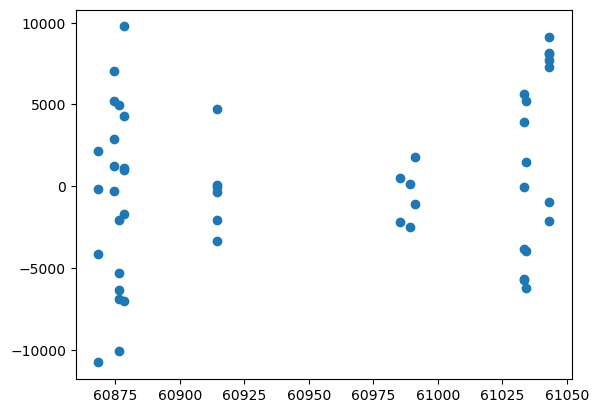

float64
amplitude = 10270.3477
beyond_1_std = 0.3600
linear_fit_slope = 8.9370
linear_fit_slope_sigma = 1.0220
linear_fit_reduced_chi2 = 43.2603


In [110]:
fx = np.where(u['band'] == 'g')[0]
plt.scatter(u['midpointMjdTai'][fx], u['psfDiffFlux'][fx])
plt.show()
#defining our variable: m, t, and err
u = u.sort_values(by = "midpointMjdTai")

err = u['psfDiffFluxErr'][fx].to_numpy().astype("float64")
t = u['midpointMjdTai'][fx].to_numpy().astype("float64")
m = u['psfDiffFlux'][fx].to_numpy().astype("float64")
#we must reorder them for feature extraction
#mask = t.argsort()
#print(mask)
# t = t[mask]
# m = m[mask]
# err = err[mask]
print(t.dtype)
# Statistical and variability feature extraction

extractor = licu.Extractor(licu.Amplitude(), licu.BeyondNStd(nstd=1), licu.LinearFit()) #add more here if you want
result = extractor(t, m, err)
print("\n".join(f"{name} = {value:.4f}" for name, value in zip(extractor.names, result)))

In [353]:
#bad_lcs2 = bad_lcs.query("diaObjectForcedSource.band == 'g'")
print(len(bad_lcs["diaObjectForcedSource.psfMagErr"]))
bad_lcs2 = bad_lcs.dropna(subset="diaObjectForcedSource.psfMagErr")
bad_lcs2 = bad_lcs2.dropna(subset="diaObjectForcedSource.psfMag")
print(len(bad_lcs2["diaObjectForcedSource.psfMagErr"]))

283105
169373


In [354]:
bad_lcs2

diaObjectForcedSource          _healpix_29
0     [{band: 'g', coord_dec: -28.196675, coord_ra: ...  2528713666380974602
1     [{band: 'g', coord_dec: -28.196735, coord_ra: ...  2528713666714509580
...                                                 ...                  ...
1090  [{band: 'g', coord_dec: -28.005428, coord_ra: ...  2528742752753587913
1091  [{band: 'z', coord_dec: -28.004336, coord_ra: ...  2528742758208346296

[1092 rows x 2 columns]

In [362]:
bad_lcs2["diaObjectForcedSource.band"]

0       g
0       g
       ..
1091    i
1091    i
Name: band, Length: 157198, dtype: string[pyarrow]

In [371]:
bands = ["g","r","i","z"]
bad_lcs2["diaObjectForcedSource"] = bad_lcs2["diaObjectForcedSource"][bad_lcs2["diaObjectForcedSource.band"].isin(bands)]
for band in bands:
    print(bad_lcs2["diaObjectForcedSource"][bad_lcs2["diaObjectForcedSource.band"]==band].len() > 10)
    mask = bad_lcs2["diaObjectForcedSource"][bad_lcs2["diaObjectForcedSource.band"]==band].len() > 10
    bad_lcs3 = bad_lcs2[mask]
bad_lcs3

[ True  True  True ... False False False]
[ True  True  True ... False False False]
[ True  True  True ...  True  True  True]
[ True  True  True ... False False False]


diaObjectForcedSource          _healpix_29
0     [{band: 'g', coord_dec: -28.196675, coord_ra: ...  2528713666380974602
1     [{band: 'g', coord_dec: -28.196735, coord_ra: ...  2528713666714509580
...                                                 ...                  ...
1087  [{band: 'g', coord_dec: -28.00366, coord_ra: 5...  2528742749098079830
1088  [{band: 'g', coord_dec: -28.003178, coord_ra: ...  2528742749123550810

[724 rows x 2 columns]

In [374]:
bad_lcs2.shape

(1092, 2)

In [376]:
bands = ["g","r","i","z"]

bad_lcs2["diaObjectForcedSource"] = bad_lcs2["diaObjectForcedSource"][bad_lcs2["diaObjectForcedSource.band"].isin(bands)]
for band in bands:
    mask = bad_lcs2["diaObjectForcedSource"][bad_lcs2["diaObjectForcedSource.band"]==band].len() > 10
    bad_lcs2 = bad_lcs2[mask]

bad_lcs2["diaObjectForcedSource.t"] = np.asarray(bad_lcs2["diaObjectForcedSource.midpointMjdTai"] - 58000, dtype=np.float32)

#light-curve features

feature = licu.Extractor(licu.Amplitude(bands=bands), licu.InterPercentileRange(quantile=0.25,bands = bands),
                        licu.AndersonDarlingNormal(bands=bands),
                        licu.BeyondNStd(bands=bands),
                        licu.Chi2Pvar(bands=bands),
                        licu.Cusum(bands=bands),
                        licu.Eta(bands=bands),
                        licu.EtaE(bands=bands),	
                        licu.ExcessVariance(bands=bands),
                        licu.Kurtosis(bands=bands),
                        licu.LaflerKinmanStringLength(bands=bands),
                        licu.MaximumSlope(bands=bands),
                        licu.Mean(bands=bands),
                        licu.MeanVariance(bands=bands),
                        licu.Median(bands=bands),
                        licu.MedianAbsoluteDeviation(bands=bands),
                        licu.MedianBufferRangePercentage(bands=bands),	
                        licu.OtsuSplit(bands=bands),
                        licu.PercentAmplitude(bands=bands),	
                        licu.PercentDifferenceMagnitudePercentile(bands=bands),
                        licu.ReducedChi2(bands=bands),
                        licu.Roms(bands=bands),
                        licu.Skew(bands=bands),
                        licu.StandardDeviation(bands=bands),
                        licu.StetsonK(bands=bands),
                        licu.WeightedMean(bands=bands)
                        )

result = feature.many(pa.array(bad_lcs2["diaObjectForcedSource"]), n_jobs=-1,
                       arrow_fields={"t": "t", "m": "psfMag", "sigma": "psfMagErr", "band": "band"})


bad_lcs_w_feats = bad_lcs2.assign(**dict(zip(feature.names, result.T)))
bad_lcs_w_feats.head()

/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/lib/python3.13/site-packages/nested_pandas/nestedframe/core.py:339: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/lib/python3.13/site-packages/nested_pandas/nestedframe/core.py:339: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/lib/python3.13/site-packages/nested_pandas/nestedframe/c

diaObjectForcedSource          _healpix_29  \
0  [{band: 'g', coord_dec: -28.196675, coord_ra: ...  2528713666380974602   
1  [{band: 'g', coord_dec: -28.196735, coord_ra: ...  2528713666714509580   
2  [{band: 'g', coord_dec: -28.196414, coord_ra: ...  2528713666747677535   
3  [{band: 'g', coord_dec: -28.19636, coord_ra: 5...  2528713666765154424   
4  [{band: 'g', coord_dec: -28.195129, coord_ra: ...  2528713667032443487   

   amplitude_g  amplitude_r  amplitude_i  amplitude_z  \
0     2.448941     2.782681     2.504981     3.019571   
1     2.545177     2.745509     2.424264     3.084994   
2     2.419602     2.824172     2.589491     2.894486   
3     2.266070     2.661101     2.491741     2.747439   
4     2.036222     2.235337     2.270577     2.787828   

   inter_percentile_range_25_g  inter_percentile_range_25_r  \
0                     2.506794                     3.018135   
1                     2.403191                     3.325251   
2                     2.877198                     3.136152   
3                     2.428410                     3.250517   
4                     1.400599                     1.834656   

   inter_percentile_range_25_i  inter_percentile_range_25_z  ...  \
0                     1.475653                     2.723627  ...   
1                     1.274618                     2.947193  ...   
2                     1.500143                     3.496975  ...   
3                     1.495449                     2.724710  ...   
4                     1.430807                     2.039597  ...   

   standard_deviation_i  standard_deviation_z  stetson_K_g  stetson_K_r  \
0              1.107361              1.645756     0.884801     0.780842   
1              1.028222              1.707887     0.874785     0.804579   
2              1.270939              1.807593     0.899332     0.892619   
3              1.094260              1.572174     0.880829     0.870317   
4              0.998133              1.294012     0.766450     0.792266   

   stetson_K_i  stetson_K_z  weighted_mean_g  weighted_mean_r  \
0     0.817019     0.854394        17.446461        17.356544   
1     0.827474     0.837047        18.205927        18.160784   
2     0.890266     0.953821        15.184356        15.495383   
3     0.867871     0.932358        16.154682        16.269783   
4     0.778448     0.833037        21.878979        21.813772   

   weighted_mean_i  weighted_mean_z  
0        17.974993        16.866800  
1        18.496145        17.423204  
2        15.910540        14.750204  
3        16.751596        15.736870  
4        21.757078        20.793583  

[5 rows x 118 columns]